In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

In [ ]:
digits=load_digits(as_frame=True)
df=digits.frame
print(df.head())

   pixel_0_0  pixel_0_1  pixel_0_2  pixel_0_3  pixel_0_4  pixel_0_5  \
0        0.0        0.0        5.0       13.0        9.0        1.0   
1        0.0        0.0        0.0       12.0       13.0        5.0   
2        0.0        0.0        0.0        4.0       15.0       12.0   
3        0.0        0.0        7.0       15.0       13.0        1.0   
4        0.0        0.0        0.0        1.0       11.0        0.0   

   pixel_0_6  pixel_0_7  pixel_1_0  pixel_1_1  ...  pixel_6_7  pixel_7_0  \
0        0.0        0.0        0.0        0.0  ...        0.0        0.0   
1        0.0        0.0        0.0        0.0  ...        0.0        0.0   
2        0.0        0.0        0.0        0.0  ...        0.0        0.0   
3        0.0        0.0        0.0        8.0  ...        0.0        0.0   
4        0.0        0.0        0.0        0.0  ...        0.0        0.0   

   pixel_7_1  pixel_7_2  pixel_7_3  pixel_7_4  pixel_7_5  pixel_7_6  \
0        0.0        6.0       13.0       10.0

In [ ]:
x=df.drop(columns='target')
y=df['target']
print(x.shape)
print(y.shape)

(1797, 64)
(1797,)


In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42)

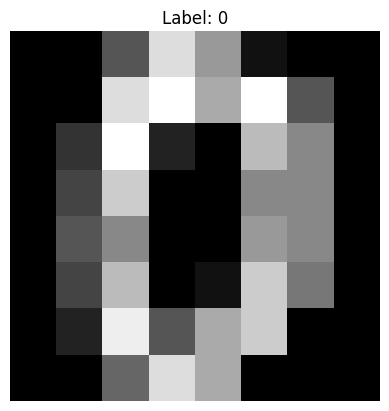

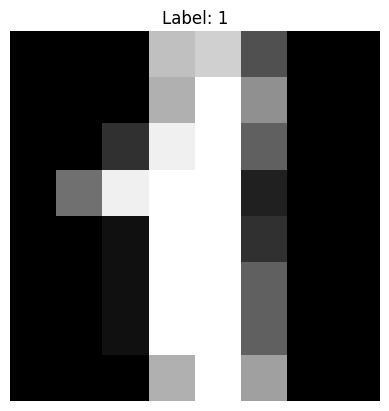

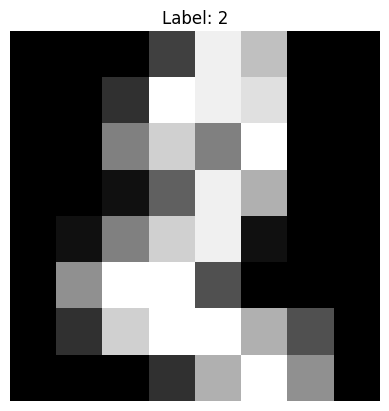

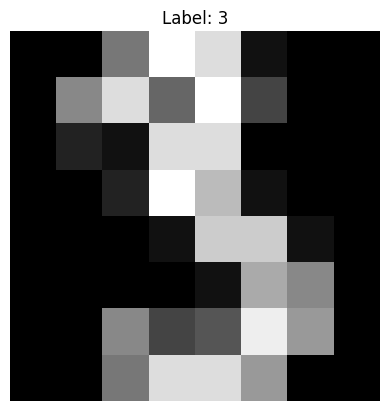

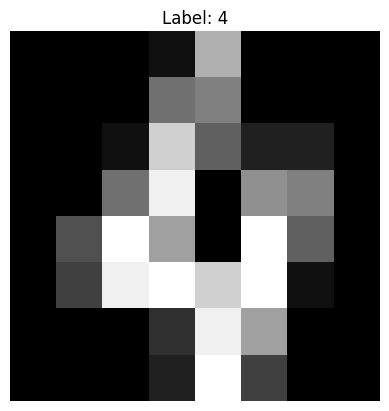

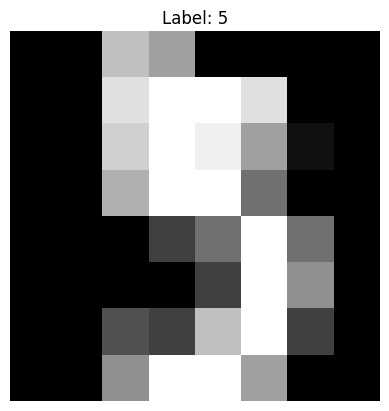

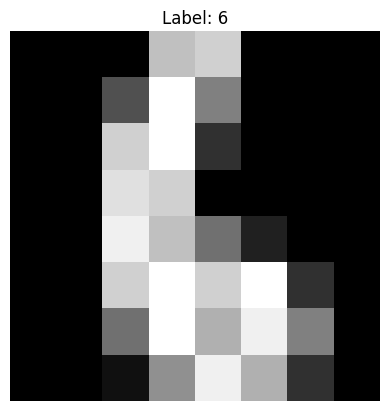

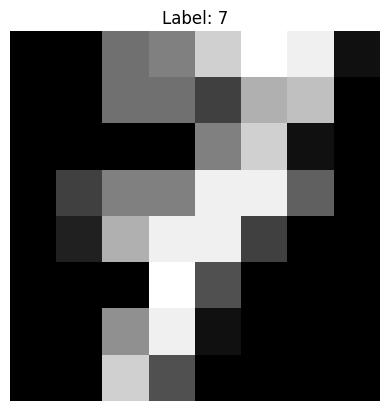

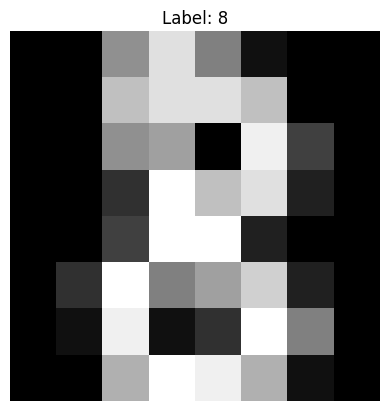

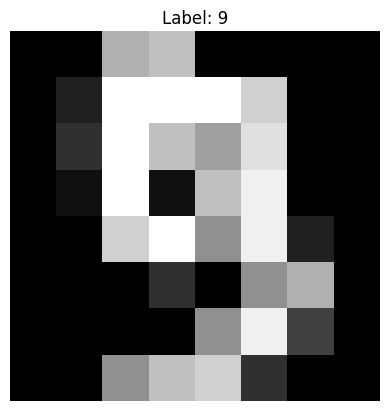

In [ ]:
for i in range(10):
  image=digits.images[i]
  plt.imshow(image,cmap='gray')
  plt.title(f"Label: {digits.target[i]}")
  plt.axis('off')
  plt.savefig(f'verification:{i + 1}:image.png')
  plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler
ss=StandardScaler().set_output(transform='pandas')
x_train_s=ss.fit_transform(x_train)
x_test_s=ss.fit_transform(x_test)
print(x.head())

   pixel_0_0  pixel_0_1  pixel_0_2  pixel_0_3  pixel_0_4  pixel_0_5  \
0        0.0        0.0        5.0       13.0        9.0        1.0   
1        0.0        0.0        0.0       12.0       13.0        5.0   
2        0.0        0.0        0.0        4.0       15.0       12.0   
3        0.0        0.0        7.0       15.0       13.0        1.0   
4        0.0        0.0        0.0        1.0       11.0        0.0   

   pixel_0_6  pixel_0_7  pixel_1_0  pixel_1_1  ...  pixel_6_6  pixel_6_7  \
0        0.0        0.0        0.0        0.0  ...        0.0        0.0   
1        0.0        0.0        0.0        0.0  ...        0.0        0.0   
2        0.0        0.0        0.0        0.0  ...        5.0        0.0   
3        0.0        0.0        0.0        8.0  ...        9.0        0.0   
4        0.0        0.0        0.0        0.0  ...        0.0        0.0   

   pixel_7_0  pixel_7_1  pixel_7_2  pixel_7_3  pixel_7_4  pixel_7_5  \
0        0.0        0.0        6.0       13.0

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier(n_neighbors=3)
knn.fit(x_train_s,y_train)
kscores=[3,5,7,9]
accuracies=[]

In [ ]:
from sklearn.metrics import accuracy_score,confusion_matrix


In [ ]:
y_pred=knn.predict(x_test_s)
accuracies.append(accuracy_score(y_test,y_pred))


In [ ]:
knn=KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train_s,y_train)
y_pred=knn.predict(x_test_s)
accuracies.append(accuracy_score(y_test,y_pred))

In [ ]:
knn=KNeighborsClassifier(n_neighbors=7)
knn.fit(x_train_s,y_train)
y_pred=knn.predict(x_test_s)
accuracies.append(accuracy_score(y_test,y_pred))

In [ ]:
knn=KNeighborsClassifier(n_neighbors=9)
knn.fit(x_train_s,y_train)
y_pred=knn.predict(x_test)
accuracies.append(accuracy_score(y_test,y_pred))

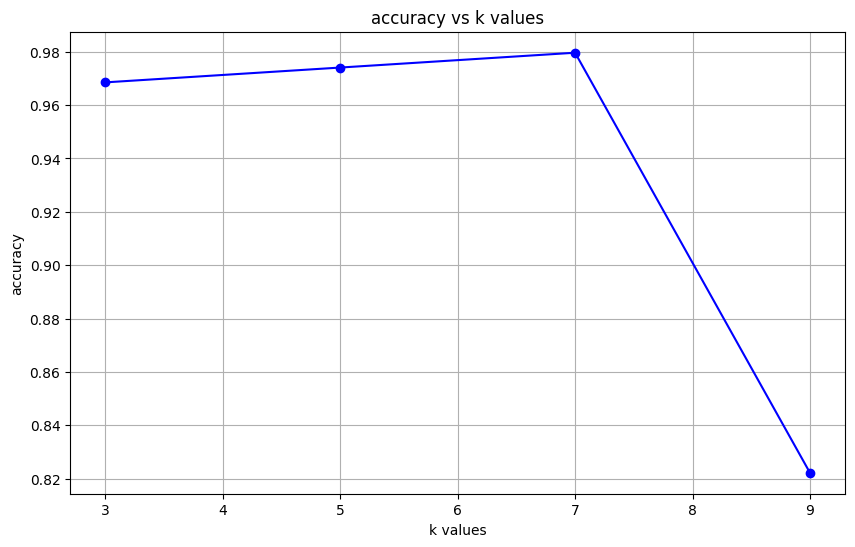

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(kscores,accuracies,marker='o',linestyle='-',color='b')
plt.title("accuracy vs k values")
plt.xlabel("k values")
plt.ylabel("accuracy")
plt.grid(True)
plt.show()

In [ ]:
knn=KNeighborsClassifier(n_neighbors=7)
knn.fit(x_train_s,y_train)
y_pred=knn.predict(x_test_s)
cm=confusion_matrix(y_test,y_pred)
cm



array([[53,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0, 50,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0, 47,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0, 54,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0, 60,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0, 63,  1,  0,  0,  2],
       [ 0,  0,  0,  0,  0,  0, 53,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  1,  0, 53,  0,  1],
       [ 0,  1,  0,  0,  0,  0,  0,  0, 42,  0],
       [ 0,  0,  0,  2,  1,  1,  1,  0,  0, 54]])